In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("placement.csv")

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


# STEPS
1. Preprocess+ EDA+ Feature selection
   Preprocess means we prepare the data for the process like cleaning and all,      EDA means exploratory data analysis which means drawing graphs and figures       for data to find the deep knowledge of what data wants to tell. And then we      select features among data to process for the output.
3. Extract input and output cols
4. Scale the values  
5. Train test split
6. Train the model
7. Evaluate the model/ model selection
8. Deploy the model

In [5]:
#Preprocess
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [6]:
df.shape

(100, 4)

In [7]:
df=df.iloc[:,1:] #it means we want every rows except the middle coulns which is cgpa


In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
#EDA
import matplotlib.pyplot as plt

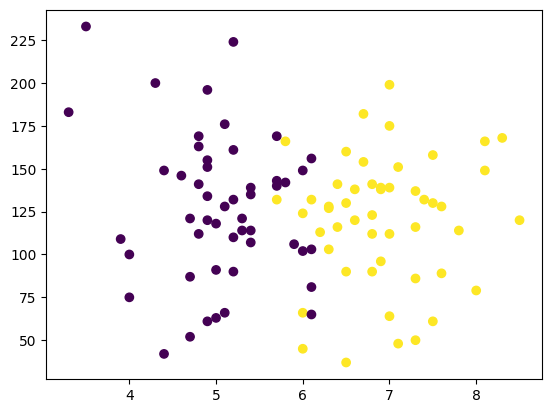

In [10]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [16]:
#int this model we are working with logistic regression

In [11]:
# feature selection
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [12]:
x  #these are independent variables

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [13]:
y.shape  #these are dependent variables

(100,)

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [15]:
x_train

,cgpa,iq
71,6.1,132.0
35,6.8,90.0
99,6.2,113.0
66,6.9,96.0
5,7.1,48.0
...,...,...
65,8.1,166.0
98,6.3,103.0
59,4.8,112.0
86,5.1,128.0


In [17]:
y_train

71    1
35    1
99    1
66    1
5     1
     ..
65    1
98    1
59    0
86    0
3     1
Name: placement, Length: 90, dtype: int64

In [18]:
x_test

,cgpa,iq
23,4.7,87.0
76,4.9,155.0
46,5.3,114.0
48,6.6,138.0
16,5.2,224.0
41,5.4,114.0
47,5.2,161.0
7,5.0,63.0
90,7.3,86.0
80,4.9,196.0


In [19]:
y_test

23    0
76    0
46    0
48    1
16    0
41    0
47    0
7     0
90    1
80    0
Name: placement, dtype: int64

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler=StandardScaler()

In [22]:
x_train=scaler.fit_transform(x_train)

In [23]:
x_train

array([[ 0.04234522,  0.24827841],
       [ 0.6486517 , -0.84299181],
       [ 0.12896043, -0.24539145],
       [ 0.73526692, -0.68709606],
       [ 0.90849734, -1.93426203],
       [-0.04427   ,  0.04041742],
       [ 1.51480383, -0.21940883],
       [-1.25688298,  0.61203515],
       [-0.99703734, -0.06351308],
       [-0.30411564,  0.4561394 ],
       [-0.99703734, -1.59648791],
       [-1.86318947, -0.34932195],
       [ 0.73526692,  0.40417416],
       [-0.30411564,  0.53408728],
       [-0.82380691,  1.39151388],
       [-0.91042213, -0.11547833],
       [-0.56396127, -0.4012872 ],
       [-0.04427   , -2.0122099 ],
       [ 1.34157341, -0.86897443],
       [-1.4301134 , -2.09015777],
       [-1.51672862,  2.01509686],
       [-0.30411564,  1.20963551],
       [-0.21750042,  0.50810465],
       [ 1.25495819,  0.19631316],
       [ 1.68803426, -1.12880068],
       [-0.56396127,  0.32622628],
       [ 0.6486517 ,  0.48212203],
       [-0.7371917 ,  0.24827841],
       [ 1.34157341,

In [24]:
x_test=scaler.fit_transform(x_test)

In [25]:
x_test

array([[-0.94754692, -0.96574733],
       [-0.69486774,  0.43747529],
       [-0.18950938, -0.40858541],
       [ 1.45290528,  0.08666963],
       [-0.31584897,  1.86133353],
       [-0.06316979, -0.40858541],
       [-0.31584897,  0.56128905],
       [-0.56852815, -1.46100237],
       [ 2.33728241, -0.98638296],
       [-0.69486774,  1.28353598]])

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
clf=LogisticRegression()

In [28]:
#Model training
clf.fit(x_train,y_train)

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


LogisticRegression()

In [29]:
y_pred=clf.predict(x_test)

In [30]:
y_test

23    0
76    0
46    0
48    1
16    0
41    0
47    0
7     0
90    1
80    0
Name: placement, dtype: int64

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy_score(y_test,y_pred)

0.9

In [33]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
  Using cached mlxtend-0.25.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
Using cached mlxtend-0.25.0-py3-none-any.whl (1.4 MB)
Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl (8.2 MB)

  Attempting uninstall: scikit-learn

    Found existing installation: scikit-learn 1.6.1

   ---------------------------------------- 0/2 [scikit-learn]
    Uninstalling scikit-learn-1.6.1:
   ---------------------------------------- 0/2 [scikit-learn]
      Successfully uninstalled scikit-learn-1.6.1
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ---------------------------------------- 0/2 [scikit-learn]
   ------------------------------------

  You can safely remove it manually.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

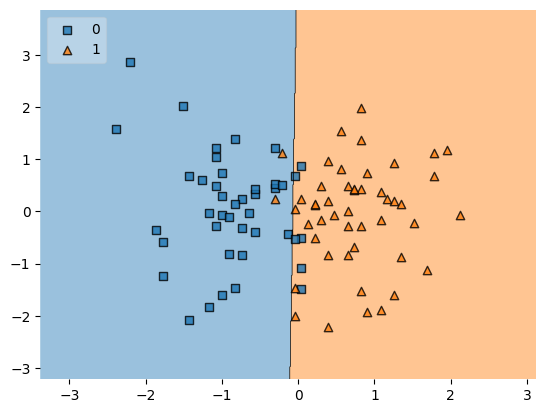

In [37]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)